# Laser Driven dynamics

Here we describe how to simulate a two-level system interacting diagonally with its environment, that is, a system undergoing decoherence without energy relaxation — the so-called *pure-dephasing* regime.

The system Hamiltonian reads

$$
H_S = \frac{\Delta\epsilon}{2} \sigma_z
$$

where $\Delta\epsilon$ is the energy difference between levels and $V$ is the diabatic coupling between levels. Under these conditions, the system-bath interaction Hamiltonian takes the form

$$
H_{SB} = Q_S \otimes X_B,
$$

where

$$
Q_S = \frac{\sigma_z}{2} \quad \text{and} \quad X_B = \sum_j c_j x_j.
$$

The relevance of studying this model lies in its ability to describe open quantum systems where relaxation processes are much slower than decoherence. In addition, this represents the prototypical model for capturing the decoherence dynamics of two-level systems in condensed-phase environments.

In our model, we consider one structured spectral density with a Drude-Loretnz and a Brownian Oscillator part

$$ 
J(\omega) = \frac{2}{\pi}\frac{\lambda\omega\omega_c}{\omega_c^2 + \omega^2}+\sum_{b=1}\frac{4}{\pi}\lambda_{b}\omega_{b}^2 \frac{\omega\gamma_{b}}{\left(\omega^2-\omega_{b}^2 \right)^2+4\omega^2\gamma_{b}^2}
$$

In [2]:
from math import ceil
import os
import json as json
import numpy as np
from tqdm import tqdm

from tenso.prototypes.heom import system_single_bath #Spin-boson helper function
from tenso.prototypes.bath import gen_bcf #Bath correlation function generator
import matplotlib.pyplot as plt
from tenso.prototypes.default_parameters import quantity


## Bath Correlation Function (BCF)

The bath correlation function encodes all the essential information required to capture the influence of the environment on the reduced density matrix of the system, $\rho_S(t)$. It is defined as

$$
C(t)=\mathrm{Tr}\bigl(\tilde{X}_B(t)\,\tilde{X}_B(0)\,\rho_B^{\mathrm{eq}}\bigr),
$$

and is related to the spectral density $J(\omega)$ through

$$
C(t)=\int_{-\infty}^{\infty} \mathcal{J}(\omega)(1-e^{-\beta \omega})^{-1}e^{-i\omega t}\mathrm{d}\omega
$$

TENSO provides two approaches for decomposing the bath correlation function into sums of exponentials: the Matsubara and the Padé schemes. In this example, we focus on the Padé decomposition following the $\left( N - 1 \right)/N$ scheme. In general, such decompositions take the form

$$
C(t) = \sum_{k=1}^{K} c_k e^{  \gamma_k t}\quad \mathrm{and} \quad C^*(t) = \sum_{k=1}^{K} \bar{c_k} e^{  \gamma_k t}
$$

The `get_bcf` function accepts different arguments depending on the choice of spectral density and decomposition method. For a Drude-Lorentz spectral density combined with a Padé decomposition, the main parameters are:

- `re_d`: The Drude-Lorentz reorganization energy, $\lambda$. This parameter should be provided as a list.
- `width_d`: The Drude-Lorentz cutoff frequency (the width of $J(\omega)$), also specified as a list.
- `freq_b`: It denotes the resonance frequency of the vibrational mode represented in the spectral density $J(\omega)$.
- `re_b`: The Underdamped Brownian reorganization energy, $\lambda$. This parameter should be provided as a list.
- `width_b`: The Underdamped Brownian cutoff frequency (the width of $J(\omega)$), also specified as a list.
- `temperature`: The bath temperature in K (float).
- `decomposition_method`: The method used for the decomposition of the BCF (string).
- `n_ltc`: The number of low-temperature corrections.


In [3]:
bath_simulation = gen_bcf(
  re_d=[540], #Reorganization energy in cm-1
  width_d=[70], #Width of the DL spectral density in cm-1
  freq_b=[1243], # Central Frequency of the Brownian Spectral density in cm-1
  re_b=[161.6], #Reorganization energy of the Brownian Spectral density in cm-1
  width_b=[10], #Width of the spectral density in cm-1
  temperature=300, #Temperature in Kelvin
  decomposition_method='Pade', #Decomposition method for the bath correlation function
  n_ltc=1, #Number of low-temperature correction terms
)


In [4]:
end_time = 40.0 # fs
dt = 0.05 # fs
wfn = np.array([0.0, 1.0], dtype=np.complex128) # Start in Ground State |0> (convention [exc, gnd])


## Time-dependent field

Here, we illustrate the implementation of a Hadamard gate in a two-level system subject exclusively to pure dephasing. The objective is to coherently drive the system from the ground state to a superposition of the form

$$
|\Psi\rangle = \frac{1}{\sqrt{2}}\left( |0\rangle + |1\rangle \right).
$$

To achieve this, we consider the full time-dependent Hamiltonian in the laboratory frame, given by

$$
H(t) = \frac{\Delta\epsilon}{2}\sigma_z - \mu E(t)\sigma_x,
$$

where the external laser field $E(t)$ is defined as a Gaussian envelope modulated by a resonant carrier frequency $\omega_L = \Delta\epsilon/\hbar$:

$$
E(t) = E_0 \exp\left(-\frac{(t-t_0)^2}{2\sigma^2}\right) \cos(\omega_L t).
$$

To implement a Hadamard gate, which corresponds to a $\pi/2$ rotation on the Bloch sphere, the pulse amplitude must be carefully calibrated. Although the target rotation angle is $\pi/2$, the oscillating nature of the carrier field requires the envelope area to be $\pi$ to achieve the correct effective coupling strength. According to the area theorem, the required peak amplitude is

$$
E_0 = \frac{\pi \hbar}{\mu\sigma\sqrt{2\pi}}.
$$

In [5]:
import numpy as np

# ==========================================
# 1. PHYSICAL CONSTANTS & UNIT CONVERSIONS
# ==========================================
# --- Standard SI Constants ---
h_Js          = 6.62607015e-34      # Planck constant (J*s)
hbar_Js       = 1.054571817e-34     # Reduced Planck constant (J*s)
c_ms          = 299792458.0         # Speed of light (m/s)
c_cms         = c_ms * 100.0        # Speed of light (cm/s)

# --- Atomic Unit Conversions ---
Hartree_to_cm = 219474.6313705 
fs_to_au      = 41.341374576 

# ==========================================
# 2. INPUT PARAMETERS
# ==========================================
# --- System Parameters ---
delta_Eps_cm  = 1500.0              # Energy gap in cm^-1
mu_au         = 3.31356454592       # Dipole moment (a.u.)

# --- Drive (Laser) Parameters ---
FWHM_fs       = 5.0                 # Pulse duration (FWHM) in fs
t0_fs         = 6.0                 # Pulse center time in fs
target_area   = np.pi               # Target pulse area (Pi pulse)

# ==========================================
# 3. CALCULATIONS & CONVERSIONS
# ==========================================

# --- A. Frequency Conversion (cm^-1 -> rad/fs) ---
# 1. Convert cm^-1 to Joules (E = h * c * wavenumber)
E_Joules = delta_Eps_cm * h_Js * c_cms

# 2. Convert Joules to Angular Frequency in rad/s (omega = E / hbar)
omega_rad_s = E_Joules / hbar_Js

# 3. Convert rad/s to rad/fs (1 fs = 1e-15 s)
omega_rad_fs = omega_rad_s * 1e-15

# --- B. Field Amplitude & Envelope ---
# 1. Convert FWHM to Gaussian Sigma
sigma_fs = FWHM_fs / (2 * np.sqrt(2 * np.log(2)))

# 2. Convert Sigma to Atomic Units (needed for Area calculation)
sigma_au_val = sigma_fs * fs_to_au

# 3. Calculate Electric Field Amplitude (E0) in a.u.
# Formula: Area = mu * E0 * sigma * sqrt(2*pi)
E0_au = target_area / (mu_au * sigma_au_val * np.sqrt(2 * np.pi))

# 4. Convert Max Interaction Energy to cm^-1
interaction_max_cm = (mu_au * E0_au) * Hartree_to_cm

# ==========================================
# 4. LASER FIELD FUNCTION
# ==========================================

def laser_field_hadamard(t):
    """
    Returns the laser field interaction energy at time t.
    t: Time in femtoseconds (fs)
    """
    # Gaussian Envelope
    # Unitless argument inside exp: (fs / fs)^2
    envelope = np.exp(-0.5 * ((t - t0_fs) / sigma_fs)**2)
    
    # Oscillatory Carrier
    # Unitless argument inside cos: (rad/fs) * fs = radians
    carrier = np.cos(omega_rad_fs * t)
    
    return -interaction_max_cm * envelope * carrier

# ==========================================
# 5. OUTPUT & VERIFICATION
# ==========================================
print(f"--- Frequency Conversion Details ---")
print(f"Energy Gap:       {delta_Eps_cm} cm^-1")
print(f"Energy in Joules: {E_Joules:.4e} J")
print(f"Omega in rad/s:   {omega_rad_s:.4e} rad/s")
print(f"Omega in rad/fs:  {omega_rad_fs:.5f} rad/fs")
print(f"\n--- Pulse Details ---")
print(f"Max Interaction:  {interaction_max_cm:.2f} cm^-1")
print(f"Pulse Width:      {sigma_fs:.3f} fs")

--- Frequency Conversion Details ---
Energy Gap:       1500.0 cm^-1
Energy in Joules: 2.9797e-20 J
Omega in rad/s:   2.8255e+14 rad/s
Omega in rad/fs:  0.28255 rad/fs

--- Pulse Details ---
Max Interaction:  3133.63 cm^-1
Pulse Width:      2.123 fs


In [6]:
propagator = system_single_bath(
  fname='laser_example3',
  init_rdo=np.outer(wfn, wfn.conj()),
  sys_ham=np.array([[delta_Eps_cm/2, 0.0], [0.0, -delta_Eps_cm/2]], dtype=np.complex128),#System Hamiltonian
  sys_op=np.array([[0.5, 0.0], [0.0, -0.5]], dtype=np.complex128),#System operator (sigma_z/2)
  bath_correlation=bath_simulation,
  td_f=laser_field_hadamard,#Laser field
  td_op = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=np.complex128),# light-matter coupling (sigma_x)
  dim=30,
  end_time=end_time,
  step_time=dt,
  save_checkpoint_to_file=True,
)

progress_bar = tqdm(propagator, total=ceil(end_time / dt))
for _t in (progress_bar):
  progress_bar.set_description(f'@{_t:.2f} fs')


  0%|          | 0/800 [00:00<?, ?it/s]

{'dim': 30, 'end_time': 40.0, 'step_time': 0.05, 'save_checkpoint_to_file': True}
{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 30, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 40.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 32, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': True, 'start_time': 0.0, 'step_time': 0.05, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}
For k=0: s:0.22307229 | e:0.00000000 | a:-0.03780000 | f:0.47230529 | f^2:0.22307229
For k=1: s:0.10095920 | e:0.10044090 | a:0.00002494 | f:-0.31774078 | f^2:0.10095920
For k=2: s:0.10095920 | e:-0.10044090 | a:-0.00002494 | f:0.31774078 | f^2:0.10095920
For k=3: s:0.0479

@7.60 fs:  19%|█▉        | 153/800 [01:03<06:04,  1.77it/s]

Switched to vmf.


@39.95 fs: 100%|██████████| 800/800 [04:23<00:00,  3.03it/s]


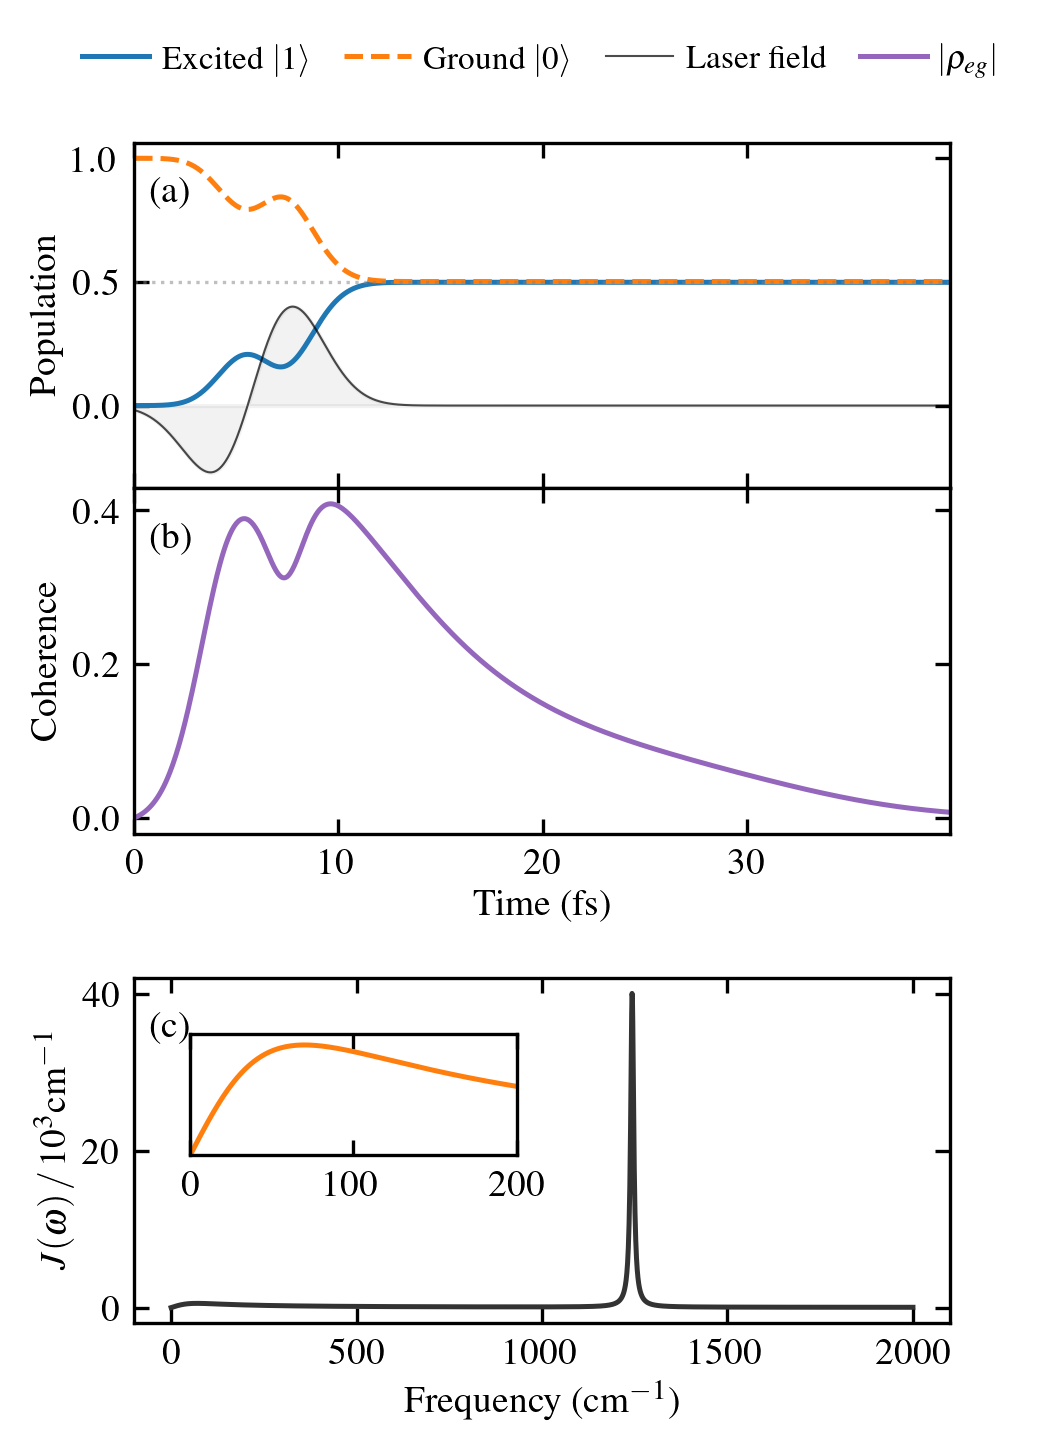

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -------------------- CONFIGURATION & PARAMETERS --------------------

# --- 1. Laser Physics Constants ---
Hartree_to_cm = 219474.6313705
fs_to_au      = 41.341374576
cm_to_Ha      = 1.0 / Hartree_to_cm

# System Parameters
delta_Eps_cm = 1500.0           
delta_Eps_au = delta_Eps_cm * cm_to_Ha
mu_au        = 3.31356454592    

# Drive parameters
FWHM_fs = 5.0
sigma_fs = FWHM_fs / (2 * np.sqrt(2 * np.log(2))) 
t0_fs = 6.0                                       

# Laser Amplitude Calculation
sigma_au = sigma_fs * fs_to_au
target_envelope_area = np.pi 
E0_au = target_envelope_area / (mu_au * sigma_au * np.sqrt(2 * np.pi))
interaction_max_cm = (mu_au * E0_au) * Hartree_to_cm

# --- 2. Full Laser Function ---
def get_laser_field(t_fs_array):
    t_au = t_fs_array * fs_to_au
    envelope = np.exp(-0.5 * ((t_fs_array - t0_fs) / sigma_fs)**2)
    carrier = np.cos(delta_Eps_au * t_au)
    return -interaction_max_cm * envelope * carrier

# --- 3. Spectral Density Parameters ---
re_d, width_d = [540], [70]
freq_b, re_b, width_b = [1243], [161.6], [10]

# --- 4. Style Settings ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif", "font.serif": ["Times"], "font.size": 9,
    "axes.labelsize": 9, "axes.titlesize": 9, "axes.linewidth": 0.8,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "figure.dpi": 300,
})

# -------------------- DATA PROCESSING --------------------

# Load Data
try:
    data = np.loadtxt("laser_example3.dat.log", dtype=np.complex128)
    t_plot = data[:, 0].real
    pop_exc = data[:, 1].real
    coh_eg = data[:, 2] 
    coh_mag = np.abs(coh_eg)
    pop_gnd = data[:, 4].real
except OSError:
    t_plot = np.linspace(0, 50, 500)
    step = 0.5 * (1 + np.tanh((t_plot - t0_fs)/2))
    pop_exc = 0.5 * step * (1 - 0.1*np.cos(0.5*t_plot))
    pop_gnd = 1.0 - pop_exc
    coh_mag = 0.4 * np.exp(-(t_plot-t0_fs)**2/10) + 0.1*step

# Laser Trace
laser_vals = get_laser_field(t_plot)
norm_factor = 0.4 / np.max(np.abs(laser_vals))
laser_plot_visual = laser_vals * norm_factor

# Spectral Density
omega = np.linspace(0, 2000, 2000)
def drude_sd(omega, re_d, width_d):
    J = np.zeros_like(omega)
    for lam, gamma in zip(re_d, width_d):
        J += 2 * lam * gamma * omega / (omega**2 + gamma**2)
    return J
def brownian_sd(omega, re_b, freq_b, width_b):
    J = np.zeros_like(omega)
    for lam, w0, gamma in zip(re_b, freq_b, width_b):
        J += 2 * lam * w0**2 * gamma * omega / ((w0**2 - omega**2)**2 + (gamma*omega)**2)
    return J
J_dl = drude_sd(omega, re_d, width_d)
J_tot = J_dl + brownian_sd(omega, re_b, freq_b, width_b)

# -------------------- PLOTTING --------------------

# Create Figure
fig = plt.figure(figsize=(3.4, 4.8))

# Define TWO GridSpecs to separate Time Domain (Top) from Freq Domain (Bottom)
# gs_top: 2 rows (Pop + Coh), 0 space between them
gs_top = fig.add_gridspec(nrows=2, ncols=1, left=0.15, right=0.95, bottom=0.42, top=0.90, hspace=0.0)

# gs_bot: 1 row (Spectral), separate from top
gs_bot = fig.add_gridspec(nrows=1, ncols=1, left=0.15, right=0.95, bottom=0.08, top=0.32)

# Create Axes
ax1 = fig.add_subplot(gs_top[0])
ax2 = fig.add_subplot(gs_top[1], sharex=ax1) # Share X axis
ax3 = fig.add_subplot(gs_bot[0])

# Helper for inside labels with small background to prevent overlap
def add_inside_label(ax, text, x=0.02, y=0.90):
    ax.text(x, y, text, transform=ax.transAxes, fontsize=9, va="top", ha="left",
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# --- PANEL (a): POPULATIONS ---
l1, = ax1.plot(t_plot, pop_exc, color='tab:blue', label=r"Excited $|1\rangle$")
l2, = ax1.plot(t_plot, pop_gnd, '--', color='tab:orange', label=r"Ground $|0\rangle$")
l_las, = ax1.plot(t_plot, laser_plot_visual, 'k-', linewidth=0.5, alpha=0.7, label=r"Laser field")
ax1.fill_between(t_plot, 0, laser_plot_visual, color='k', alpha=0.05)
ax1.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

ax1.set_ylabel("Population", labelpad=2) # Reduced labelpad
ax1.set_xlim(t_plot[0], t_plot[-1])
# Hide X ticks for the top plot since they share axis
ax1.tick_params(labelbottom=False) 
add_inside_label(ax1, "(a)")

# --- PANEL (b): COHERENCES ---
l3, = ax2.plot(t_plot, coh_mag, color='tab:purple', label=r"$|\rho_{eg}|$")

ax2.set_ylabel("Coherence", labelpad=2) # Reduced labelpad
ax2.set_xlabel("Time (fs)", labelpad=2)
ax2.set_xlim(t_plot[0], t_plot[-1])
add_inside_label(ax2, "(b)")

# --- PANEL (c): SPECTRAL DENSITY ---
ax3.plot(omega, J_tot / 1000, color="0.2", label=r"$J(\omega)$")

ax3.set_ylabel(r"$J(\omega)\,/\,10^3\mathrm{cm}^{-1}$", labelpad=2) # Reduced labelpad
ax3.set_xlabel(r"Frequency (cm$^{-1}$)", labelpad=2)
add_inside_label(ax3, "(c)")

# Inset
axins = inset_axes(ax3, width="40%", height="35%", loc="upper left", borderpad=1.5)
axins.plot(omega, J_dl, color="C1", linewidth=1.2)
axins.set_xlim(0, 200)
axins.set_ylim(0, J_dl[omega <= 200].max() * 1.1)
axins.set_xticks([0, 100, 200])
axins.set_yticks([])

# -------------------- LEGEND --------------------
handles = [l1, l2, l_las, l3]
labels  = [h.get_label() for h in handles]

fig.legend(handles, labels, 
           loc="upper center",
           bbox_to_anchor=(0.55, 0.99), # Centered horizontally
           ncol=4, 
           fontsize=8,
           frameon=False, 
           columnspacing=1.0,
           handletextpad=0.4) 

plt.savefig("three_panel_shared_axis.png", bbox_inches='tight', dpi=300, transparent=True)
plt.show()